# Task 2: Text Processing and Normalization (15%)

In [ ]:
#Import tools for text preprocessing, data manipulation and visualization.
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

#natural language processing toolkit
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'never', 'no', 'nor', 'none'}  #stop words are commonly used words that are often removed from text data during preprocessing to improve the performance of natural language processing models.
lemmatizer = WordNetLemmatizer()#Lemmatization is the process of reducing words to their base or root form, known as a lemma. This helps in normalizing the text data and improving the performance of natural language processing models.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\visha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
#used https://www.kaggle.com/code/nmaguette/up-to-date-list-of-slangs-for-text-preprocessing - a notebook with a comprehensive list of slang and abbreviations to expand in the preprocessing pipeline.More abbreviations were added to the list as well.
abbreviations = {
    "$" : " dollar ",
    "€" : " euro ",
    "4ao" : "for adults only",
    "a.m" : "before midday",
    "a3" : "anytime anywhere anyplace",
    "aamof" : "as a matter of fact",
    "acct" : "account",
    "adih" : "another day in hell",
    "afaic" : "as far as i am concerned",
    "afaict" : "as far as i can tell",
    "afaik" : "as far as i know",
    "afair" : "as far as i remember",
    "afk" : "away from keyboard",
    "app" : "application",
    "approx" : "approximately",
    "apps" : "applications",
    "asap" : "as soon as possible",
    "asl" : "age, sex, location",
    "atk" : "at the keyboard",
    "ave." : "avenue",
    "aymm" : "are you my mother",
    "ayor" : "at your own risk", 
    "b&b" : "bed and breakfast",
    "b+b" : "bed and breakfast",
    "b.c" : "before christ",
    "b2b" : "business to business",
    "b2c" : "business to customer",
    "b4" : "before",
    "b4n" : "bye for now",
    "b@u" : "back at you",
    "bae" : "before anyone else",
    "bak" : "back at keyboard",
    "bbbg" : "bye bye be good",
    "bbc" : "british broadcasting corporation",
    "bbias" : "be back in a second",
    "bbl" : "be back later",
    "bbs" : "be back soon",
    "be4" : "before",
    "bfn" : "bye for now",
    "blvd" : "boulevard",
    "bout" : "about",
    "brb" : "be right back",
    "bros" : "brothers",
    "brt" : "be right there",
    "bsaaw" : "big smile and a wink",
    "btw" : "by the way",
    "bwl" : "bursting with laughter",
    "c/o" : "care of",
    "cet" : "central european time",
    "cf" : "compare",
    "clg": "college",
    "cm" : "centimeter",
    "cia" : "central intelligence agency",
    "csl" : "can not stop laughing",
    "cu" : "see you",
    "cul8r" : "see you later",
    "cv" : "curriculum vitae",
    "cwot" : "complete waste of time",
    "cya" : "see you",
    "cyt" : "see you tomorrow",
    "dae" : "does anyone else",
    "dbmib" : "do not bother me i am busy",
    "diy" : "do it yourself",
    "dm" : "direct message",
    "dwh" : "during work hours",
    "e123" : "easy as one two three",
    "eet" : "eastern european time",
    "eg" : "example",
    "embm" : "early morning business meeting",
    "encl" : "enclosed",
    "encl." : "enclosed",
    "etc" : "and so on",
    "faq" : "frequently asked questions",
    "fawc" : "for anyone who cares",
    "fb" : "facebook",
    "fc" : "fingers crossed",
    "fig" : "figure",
    "fimh" : "forever in my heart", 
    "ft." : "feet",
    "ft" : "featuring",
    "ftl" : "for the loss",
    "ftw" : "for the win",
    "fwiw" : "for what it is worth",
    "fyi" : "for your information",
    "g9" : "genius",
    "gahoy" : "get a hold of yourself",
    "gal" : "get a life",
    "gcse" : "general certificate of secondary education",
    "gfn" : "gone for now",
    "gg" : "good game",
    "gl" : "good luck",
    "glhf" : "good luck have fun",
    "gmt" : "greenwich mean time",
    "gmta" : "great minds think alike",
    "gn" : "good night",
    "g.o.a.t" : "greatest of all time",
    "goat" : "greatest of all time",
    "goi" : "get over it",
    "gps" : "global positioning system",
    "gr8" : "great",
    "gratz" : "congratulations",
    "gyal" : "girl",
    "h&c" : "hot and cold",
    "hp" : "horsepower",
    "hr" : "hour",
    "hlo" : "hello",
    "hrh" : "his royal highness",
    "ht" : "height",
    "ibrb" : "i will be right back",
    "ic" : "i see",
    "icq" : "i seek you",
    "icymi" : "in case you missed it",
    "idc" : "i do not care",
    "idgadf" : "i do not give a damn fuck",
    "idgaf" : "i do not give a fuck",
    "idk" : "i do not know",
    "ie" : "that is",
    "i.e" : "that is",
    "ifyp" : "i feel your pain",
    "IG" : "instagram",
    "iirc" : "if i remember correctly",
    "ilu" : "i love you",
    "ily" : "i love you",
    "imho" : "in my humble opinion",
    "imo" : "in my opinion",
    "imu" : "i miss you",
    "iow" : "in other words",
    "irl" : "in real life",
    "j4f" : "just for fun",
    "jic" : "just in case",
    "jk" : "just kidding",
    "jsyk" : "just so you know",
    "l8r" : "later",
    "lb" : "pound",
    "lbs" : "pounds",
    "ldr" : "long distance relationship",
    "lmao" : "laugh my ass off",
    "lmfao" : "laugh my fucking ass off",
    "lol" : "laughing out loud",
    "ltd" : "limited",
    "ltns" : "long time no see",
    "m8" : "mate",
    "mf" : "motherfucker",
    "mfs" : "motherfuckers",
    "ml": "machine learning",
    "mfw" : "my face when",
    "mofo" : "motherfucker",
    "mph" : "miles per hour",
    "mr" : "mister",
    "mrw" : "my reaction when",
    "ms" : "miss",
    "mte" : "my thoughts exactly",
    "nagi" : "not a good idea",
    "nbc" : "national broadcasting company",
    "nbd" : "not big deal",
    "nfs" : "not for sale",
    "ngl" : "not going to lie",
    "nhs" : "national health service",
    "nrn" : "no reply necessary",
    "nsfl" : "not safe for life",
    "nsfw" : "not safe for work",
    "nth" : "nice to have",
    "nvr" : "never",
    "nyc" : "new york city",
    "oc" : "original content",
    "og" : "original",
    "ohp" : "overhead projector",
    "oic" : "oh i see",
    "omdb" : "over my dead body",
    "omg" : "oh my god",
    "omw" : "on my way",
    "pl": "please",
    "pls" : "please",
    "plz" : "please",
    "p.a" : "per annum",
    "p.m" : "after midday",
    "pm" : "prime minister",
    "poc" : "people of color",
    "pov" : "point of view",
    "pp" : "pages",
    "ppl" : "people",
    "prw" : "parents are watching",
    "ps" : "postscript",
    "pt" : "point",
    "ptb" : "please text back",
    "pto" : "please turn over",
    "qpsa" : "what happens",
    "ratchet" : "rude",
    "rbtl" : "read between the lines",
    "rlrt" : "real life retweet", 
    "rofl" : "rolling on the floor laughing",
    "roflol" : "rolling on the floor laughing out loud",
    "rotflmao" : "rolling on the floor laughing my ass off",
    "rt" : "retweet",
    "ruok" : "are you ok",
    "sfw" : "safe for work",
    "sk8" : "skate",
    "smh" : "shake my head",
    "sq" : "square",
    "srsly" : "seriously", 
    "ssdd" : "same stuff different day",
    "tbh" : "to be honest",
    "tbs" : "tablespooful",
    "tbsp" : "tablespooful",
    "tfw" : "that feeling when",
    "thks" : "thank you",
    "tho" : "though",
    "thx" : "thank you",
    "tia" : "thanks in advance",
    "til" : "today i learned",
    "tl;dr" : "too long i did not read",
    "tldr" : "too long i did not read",
    "tmb" : "tweet me back",
    "tntl" : "trying not to laugh",
    "ttyl" : "talk to you later",
    "u" : "you",
    "u2" : "you too",
    "u4e" : "yours for ever",
    "utc" : "coordinated universal time",
    "w/" : "with",
    "w/o" : "without",
    "w8" : "wait",
    "wassup" : "what is up",
    "wb" : "welcome back",
    "wtf" : "what the fuck",
    "wtg" : "way to go",
    "wtpa" : "where the party at",
    "wuf" : "where are you from",
    "wuzup" : "what is up",
    "wywh" : "wish you were here",
    "yd" : "yard",
    "ygtr" : "you got that right",
    "ynk" : "you never know",
    "zzz" : "sleeping bored and tired",
    "r": "are",
    "y": "why",
    "n": "and",
    "ur": "your",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
}

def expand_abbreviations(text): #expand abbreviations in the text using the abbreviations dictionary
    for abbr in ["$", "€", "b&b", "b+b", "c/o", "h&c", "w/", "w/o", "b@u"]:
        if abbr in abbreviations and abbr in text:
            text = text.replace(abbr, abbreviations[abbr])
    
    # Split text into words to handle other abbreviations
    words = text.split()
    expanded = []# Create a new list to hold expanded words
    
    for word in words:
        clean_word = word.lower().strip('.,!?;:\'"') #Remove punctuation for matching
        if clean_word in abbreviations:# If the cleaned word is in the abbreviations dictionary, append the expanded form
            expanded.append(abbreviations[clean_word])
        else:
            expanded.append(word)# If not, append the original word
    return ' '.join(expanded)# Join the expanded words back into a single string


def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"  # dingbats
        u"\U000024C2-\U0001F251"  # enclosed characters
        u"\U0001F900-\U0001F9FF"  # supplemental symbols
        u"\U0001FA70-\U0001FAFF"  # extended symbols
        "]+", 
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    # Remove emojis first
    text = remove_emojis(text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Normalization (lowercase)
    text = text.lower()

    # Expand abbreviations
    text = expand_abbreviations(text)
    
    #  Handle negations before removing punctuation to preserve the meaning of negated words
    text = handle_negations(text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(tokens)

test_text = "omg lol brb! this is gr8 😂 btw idk wtf is happening"
print("Original:", test_text)
print("Processed:", preprocess(test_text))

Original: omg lol brb! this is gr8 😂 btw idk wtf is happening
Processed: oh god laughing loud right back great way not know fuck happening


In [ ]:
#Load the training and testing data from CSV files, which contain the reviews and their corresponding ratings.
df_train_data = pd.read_csv('data/train_english.csv')
df_test_data = pd.read_csv('data/test_english.csv')

# Apply preprocessing
df_train_data['processed'] = df_train_data['text'].apply(preprocess)
df_test_data['processed'] = df_test_data['text'].apply(preprocess)

print(df_train_data[['text', 'processed']].head()) #Print original and processed text for the first 5 rows of the training data to verify preprocessing


X_train = df_train_data['processed'] #Use the processed text for training
y_train = df_train_data['rating'] #Use the original 'rating' column for training labels, not the processed text

X_test = df_test_data['processed'] #Use the processed text for testing
y_test = df_test_data['rating']#Use the original 'rating' column for testing labels, not the processed text

print("\nData shapes:") #Print the shapes of the training and testing data to verify that they are correctly prepared for model training and evaluation.
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

                                                text  \
0  This place is TERRIBLE; the people in charge a...   
1  Terrible Service! And they are saying that I n...   
2  Absolutely terrible company.  They sent me to ...   
3  To find it, either park in front of the Tuesda...   
4  Mall location. Used their services for sedan. ...   

                                           processed  
0  place terrible people charge worst part far ye...  
1  terrible service saying never used service lie...  
2  absolutely terrible company sent collection wi...  
3  find either park front tuesday morning mall en...  
4  mall location used service sedan nice perhaps ...  

Data shapes:
X_train: (271897,)
y_train: (271897,)
X_test: (69907,)
y_test: (69907,)


In [ ]:

# Bag of Words
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(df_train_data['processed']) # fit on training data
X_test_bow = bow.transform(df_test_data['processed'])      # transform only, never fit on test

# TF-IDF (unigrams)
tfidf_uni = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
X_train_tfidf_uni = tfidf_uni.fit_transform(df_train_data['processed'])
X_test_tfidf_uni = tfidf_uni.transform(df_test_data['processed'])

# TF-IDF (bigrams)
tfidf_bi = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf_bi = tfidf_bi.fit_transform(df_train_data['processed'])
X_test_tfidf_bi = tfidf_bi.transform(df_test_data['processed'])

y_train = df_train_data['rating']
y_test = df_test_data['rating']

# ── Compare using a simple model ───────────────────────────────────────────────

def evaluate(name, X_train, X_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    print(f"{name:<30} Accuracy: {acc:.4f}  F1: {f1:.4f}")

evaluate("Bag of Words",        X_train_bow,       X_test_bow)
evaluate("TF-IDF Unigrams",     X_train_tfidf_uni, X_test_tfidf_uni)
evaluate("TF-IDF Bigrams",      X_train_tfidf_bi,  X_test_tfidf_bi)

Bag of Words                   Accuracy: 0.6498  F1: 0.6068
TF-IDF Unigrams                Accuracy: 0.6583  F1: 0.6164
TF-IDF Bigrams                 Accuracy: 0.6669  F1: 0.6277


              precision    recall  f1-score   support

           1       0.74      0.92      0.82     26873
           2       0.40      0.14      0.20      7909
           3       0.41      0.20      0.27      8493
           4       0.63      0.79      0.70     19607
           5       0.68      0.51      0.58      7025

    accuracy                           0.67     69907
   macro avg       0.57      0.51      0.52     69907
weighted avg       0.63      0.67      0.63     69907



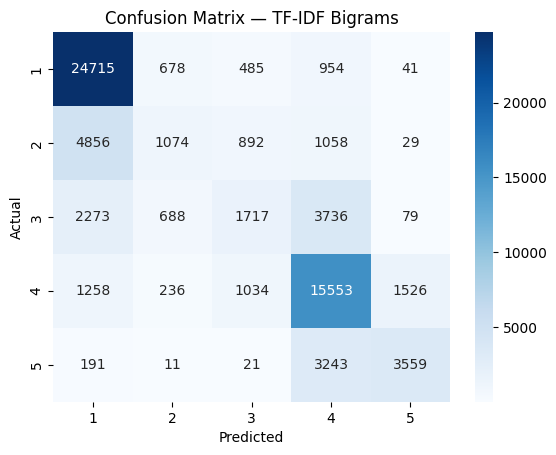

In [6]:
import seaborn as sns

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf_bi, y_train)
preds = model.predict(X_test_tfidf_bi)

print(classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — TF-IDF Bigrams')
plt.show()

              precision    recall  f1-score   support

           1       0.85      0.67      0.75     26873
           2       0.27      0.35      0.31      7909
           3       0.29      0.45      0.36      8493
           4       0.68      0.55      0.61     19607
           5       0.52      0.72      0.60      7025

    accuracy                           0.58     69907
   macro avg       0.52      0.55      0.53     69907
weighted avg       0.64      0.58      0.60     69907



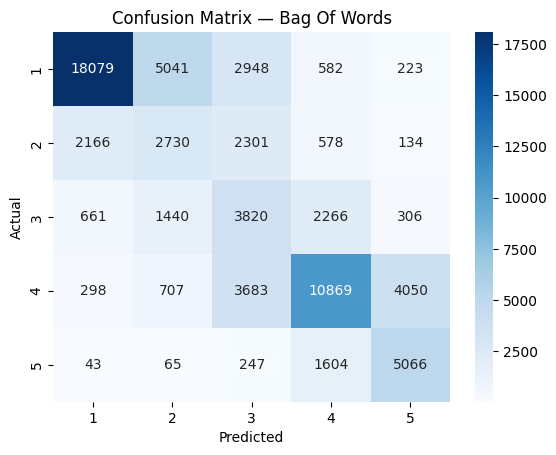

In [9]:
import seaborn as sns

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit( X_train_bow, y_train)
preds = model.predict(X_test_bow)

print(classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Bag Of Words')
plt.show()